CSV 저장 완료: RXRX_stock_with_indicators.csv

=== 최근 5개 데이터 ===
            Open  High   Low  Close    Volume   MA_5   MA_20     MA_60  \
Date                                                                     
2026-03-09  3.33  3.54  3.29   3.51  12799000  3.538  3.6105  4.150000   
2026-03-10  3.49  3.57  3.40   3.44  10074000  3.518  3.5835  4.127833   
2026-03-11  3.44  3.56  3.34   3.45  14397900  3.480  3.5635  4.109000   
2026-03-12  3.40  3.40  3.22   3.29  18345400  3.430  3.5425  4.091667   
2026-03-13  3.35  3.52  3.35   3.42  14355899  3.422  3.5345  4.078667   

              MA_120    MA_240  BB_MID  BB_UPPER  BB_LOWER     RSI_14  
Date                                                                   
2026-03-09  4.616583  4.880000  3.6105  3.915440  3.305560  41.511838  
2026-03-10  4.604917  4.867125  3.5835  3.842914  3.324086  39.647319  
2026-03-11  4.594417  4.855792  3.5635  3.796763  3.330237  40.061497  
2026-03-12  4.580750  4.844625  3.5425  3.795055  3.289945  

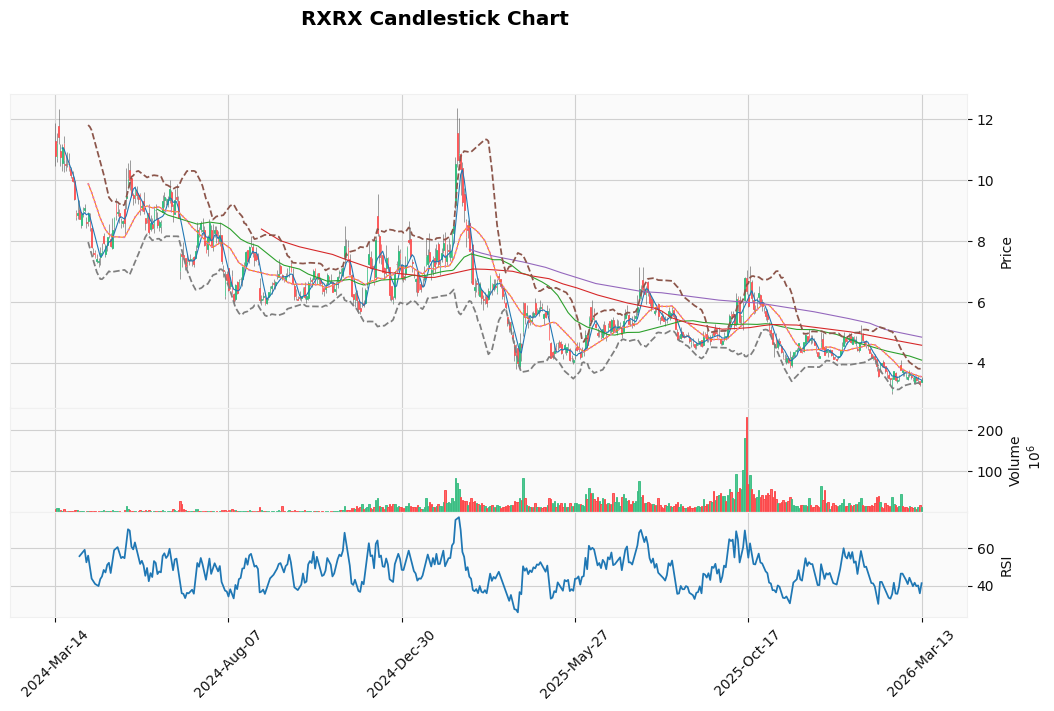

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import mplfinance as mpf


def calculate_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    """
    Wilder 방식에 가까운 RSI 계산
    """
    delta = close.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    이동평균선, 볼린저밴드, RSI 계산
    """
    result = df.copy()

    # 이동평균선
    ma_periods = [5, 20, 60, 120, 240]
    for period in ma_periods:
        result[f"MA_{period}"] = result["Close"].rolling(window=period).mean()

    # 볼린저밴드 (20일, 2표준편차)
    bb_period = 20
    bb_std = 2
    result["BB_MID"] = result["Close"].rolling(window=bb_period).mean()
    rolling_std = result["Close"].rolling(window=bb_period).std()
    result["BB_UPPER"] = result["BB_MID"] + (rolling_std * bb_std)
    result["BB_LOWER"] = result["BB_MID"] - (rolling_std * bb_std)

    # RSI
    result["RSI_14"] = calculate_rsi(result["Close"], period=14)

    return result


def get_stock_data(ticker: str, period: str = "2y", interval: str = "1d") -> pd.DataFrame:
    """
    야후 파이낸스에서 주가 데이터 다운로드
    """
    df = yf.download(
        ticker,
        period=period,
        interval=interval,
        auto_adjust=False,
        progress=False
    )

    if df.empty:
        raise ValueError(f"{ticker} 데이터가 비어 있습니다. 티커를 확인하세요.")

    # yfinance 버전에 따라 MultiIndex 컬럼이 나올 수 있음
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    required_cols = ["Open", "High", "Low", "Close", "Volume"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"필수 컬럼이 없습니다: {missing}")

    df = df[required_cols].copy()
    df.dropna(inplace=True)

    # 인덱스 이름 정리
    df.index.name = "Date"

    return df


def save_to_csv(df: pd.DataFrame, ticker: str, filename: str = None) -> str:
    """
    CSV 파일로 저장
    """
    if filename is None:
        filename = f"{ticker}_stock_with_indicators.csv"

    df_to_save = df.copy()
    df_to_save.to_csv(filename, encoding="utf-8-sig")

    return filename


def plot_candlestick(df: pd.DataFrame, ticker: str, save_chart: bool = False):
    """
    mplfinance로 캔들차트 + 이동평균 + 볼린저밴드 + 거래량 + RSI 표시
    """
    plot_df = df.copy()

    # mplfinance addplot 구성
    add_plots = [
        mpf.make_addplot(plot_df["BB_UPPER"], linestyle="dashed"),
        mpf.make_addplot(plot_df["BB_MID"], linestyle="dotted"),
        mpf.make_addplot(plot_df["BB_LOWER"], linestyle="dashed"),

        mpf.make_addplot(plot_df["RSI_14"], panel=2, ylabel="RSI"),
    ]

    chart_kwargs = dict(
        type="candle",
        mav=(5, 20, 60, 120, 240),
        volume=True,
        addplot=add_plots,
        title=f"{ticker} Candlestick Chart",
        ylabel="Price",
        ylabel_lower="Volume",
        panel_ratios=(6, 2, 2),   # 가격 / 거래량 / RSI
        figscale=1.3,
        figratio=(16, 9),
        style="yahoo"
    )

    if save_chart:
        chart_file = f"{ticker}_candlestick_chart.png"
        mpf.plot(plot_df, savefig=chart_file, **chart_kwargs)
        print(f"차트 이미지 저장 완료: {chart_file}")
    else:
        mpf.plot(plot_df, **chart_kwargs)


def main():
    ticker = "RXRX"

    # 240일 이평선 계산을 위해 기간은 넉넉히 확보
    raw_df = get_stock_data(ticker=ticker, period="2y", interval="1d")
    df = add_indicators(raw_df)

    # CSV 저장
    csv_file = save_to_csv(df, ticker)
    print(f"CSV 저장 완료: {csv_file}")

    # 최근 데이터 출력
    print("\n=== 최근 5개 데이터 ===")
    print(df.tail(5))

    print("\n=== 최근 1개 데이터 요약 ===")
    latest = df.iloc[-1]
    print(f"Date       : {df.index[-1].date()}")
    print(f"Open       : {latest['Open']:.2f}")
    print(f"High       : {latest['High']:.2f}")
    print(f"Low        : {latest['Low']:.2f}")
    print(f"Close      : {latest['Close']:.2f}")
    print(f"Volume     : {int(latest['Volume'])}")
    print(f"MA_5       : {latest['MA_5']:.2f}" if pd.notna(latest["MA_5"]) else "MA_5       : NaN")
    print(f"MA_20      : {latest['MA_20']:.2f}" if pd.notna(latest["MA_20"]) else "MA_20      : NaN")
    print(f"MA_60      : {latest['MA_60']:.2f}" if pd.notna(latest["MA_60"]) else "MA_60      : NaN")
    print(f"MA_120     : {latest['MA_120']:.2f}" if pd.notna(latest["MA_120"]) else "MA_120     : NaN")
    print(f"MA_240     : {latest['MA_240']:.2f}" if pd.notna(latest["MA_240"]) else "MA_240     : NaN")
    print(f"BB_UPPER   : {latest['BB_UPPER']:.2f}" if pd.notna(latest["BB_UPPER"]) else "BB_UPPER   : NaN")
    print(f"BB_MID     : {latest['BB_MID']:.2f}" if pd.notna(latest["BB_MID"]) else "BB_MID     : NaN")
    print(f"BB_LOWER   : {latest['BB_LOWER']:.2f}" if pd.notna(latest["BB_LOWER"]) else "BB_LOWER   : NaN")
    print(f"RSI_14     : {latest['RSI_14']:.2f}" if pd.notna(latest["RSI_14"]) else "RSI_14     : NaN")

    # 캔들차트 표시
    plot_candlestick(df, ticker, save_chart=False)


if __name__ == "__main__":
    main()